In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1024 non-null   float64
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1023 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(2), int64(12)
memory usage: 112.2 KB


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1024 non-null   float64
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1023 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(2), int64(12)
memory usage: 112.2 KB


In [5]:
print(data.describe().T)

           count        mean        std    min    25%    50%    75%    max
age       1025.0   54.434146   9.072290   29.0   48.0   56.0   61.0   77.0
sex       1025.0    0.695610   0.460373    0.0    0.0    1.0    1.0    1.0
cp        1025.0    0.942439   1.029641    0.0    0.0    1.0    2.0    3.0
trestbps  1025.0  131.611707  17.516718   94.0  120.0  130.0  140.0  200.0
chol      1025.0  246.000000  51.592510  126.0  211.0  240.0  275.0  564.0
fbs       1025.0    0.149268   0.356527    0.0    0.0    0.0    0.0    1.0
restecg   1024.0    0.529297   0.527931    0.0    0.0    1.0    1.0    2.0
thalach   1025.0  149.114146  23.005724   71.0  132.0  152.0  166.0  202.0
exang     1025.0    0.336585   0.472772    0.0    0.0    0.0    1.0    1.0
oldpeak   1023.0    1.072043   1.176008    0.0    0.0    0.8    1.8    6.2
slope     1025.0    1.385366   0.617755    0.0    1.0    1.0    2.0    2.0
ca        1025.0    0.754146   1.030798    0.0    0.0    0.0    1.0    4.0
thal      1025.0    2.323

In [6]:
print("Duplicate rows before:", data.duplicated().sum())

Duplicate rows before: 720


In [7]:
data.drop_duplicates(inplace=True)
print("Duplicates after:", data.duplicated().sum())

Duplicates after: 0


In [8]:
data.isnull().sum()
data = data.fillna(data.median())
data.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


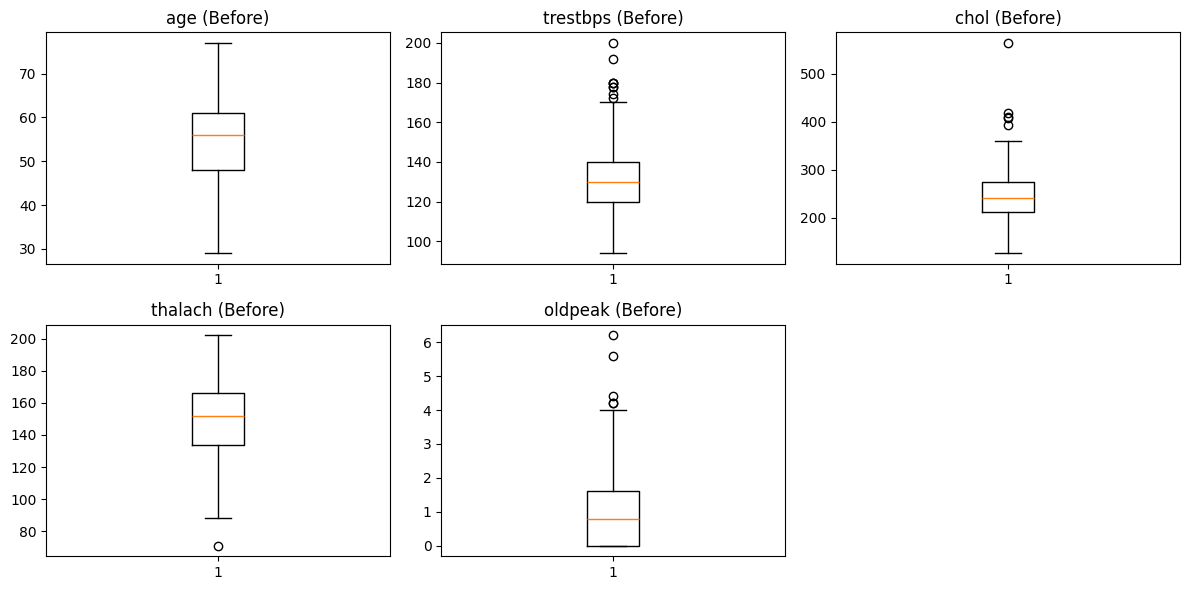

In [9]:
cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(data[col], showfliers=True)
    axes[i].set_title(f'{col} (Before)')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [10]:
cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data = data[
        (data[col] >= lower_bound) &
        (data[col] <= upper_bound)
    ]

print("Final shape after outlier removal:", data.shape)

Final shape after outlier removal: (286, 14)


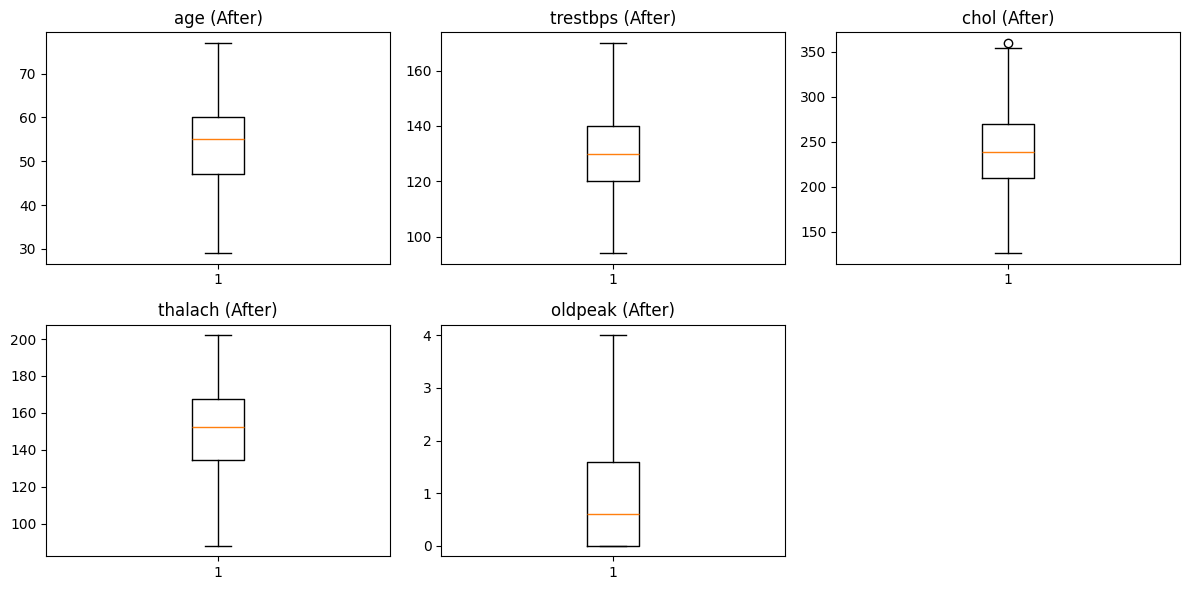

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(data[col], showfliers=True)
    axes[i].set_title(f'{col} (After)')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [12]:
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

before_cols = data.shape[1]

data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

print(f"Before encoding: {before_cols}")
print(f"After encoding: {data.shape[1]}")

data.head()

Before encoding: 14
After encoding: 23


,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,140,203,155,3.1,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,138,294,106,1.9,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [13]:
print(f"Number of columns before encoding: {before_cols}")
print(f"Number of columns after encoding: {data.shape[1]}")

Number of columns before encoding: 14
Number of columns after encoding: 23


In [14]:
from sklearn.preprocessing import MinMaxScaler

numerical_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

data_before_norm = data.copy()

scaler = MinMaxScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

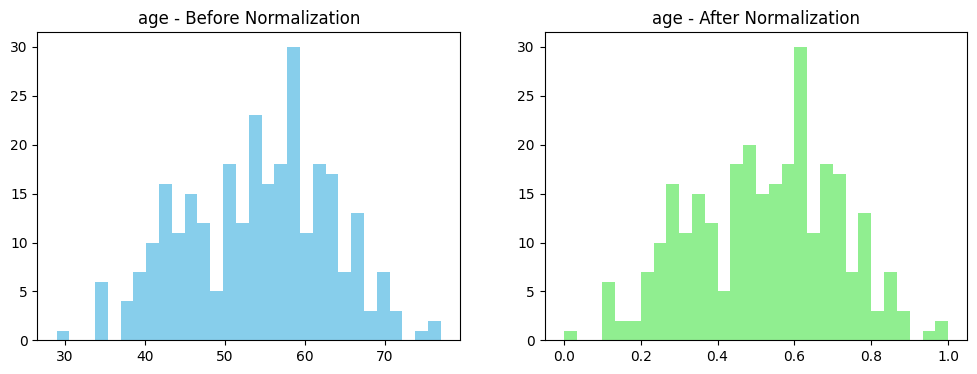

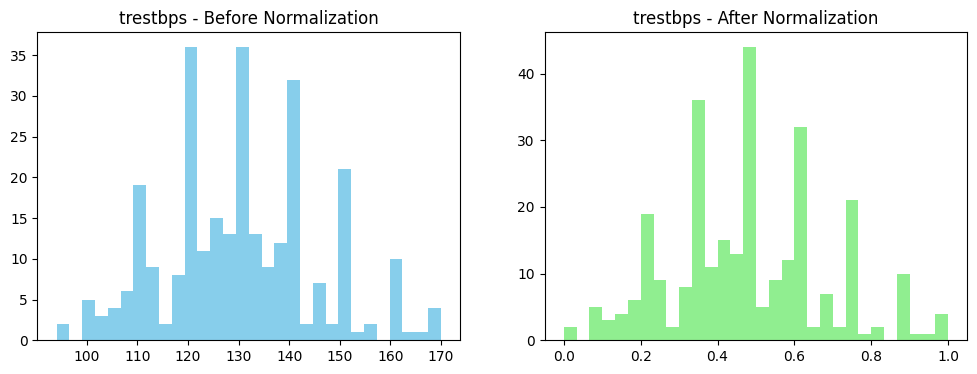

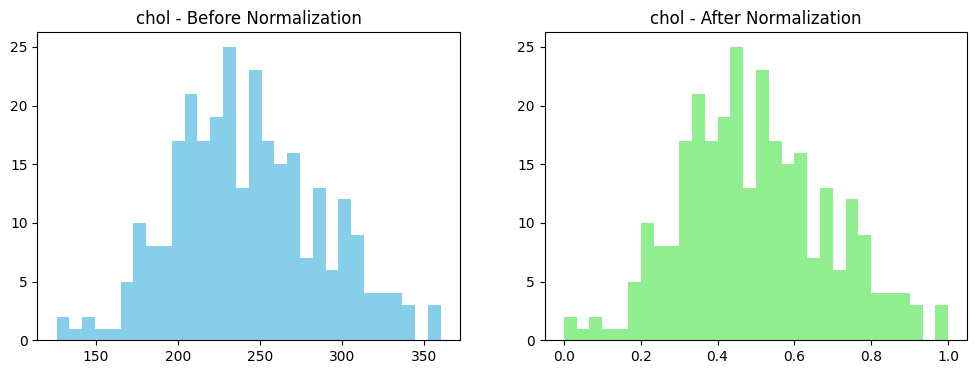

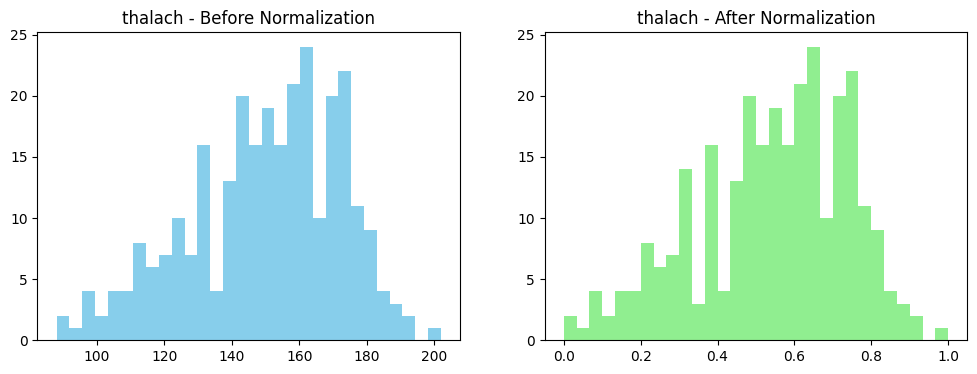

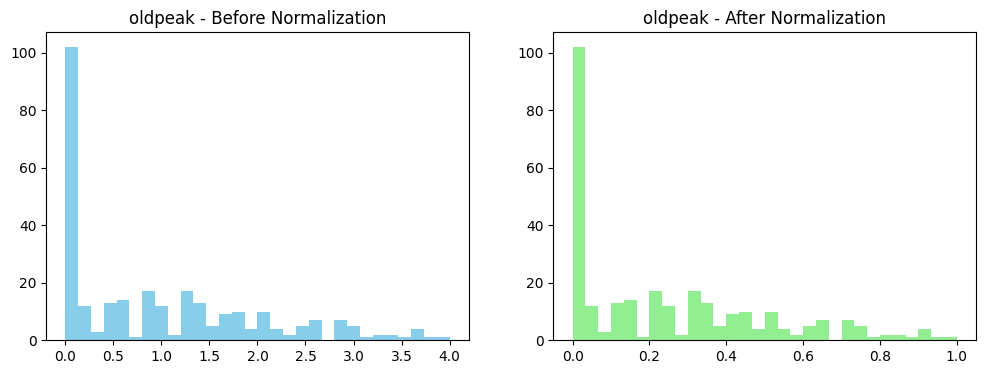

In [15]:
for column in numerical_columns:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].hist(data_before_norm[column], bins=30, color='skyblue')
    ax[0].set_title(f"{column} - Before Normalization")

    ax[1].hist(data[column], bins=30, color='lightgreen')
    ax[1].set_title(f"{column} - After Normalization")

    plt.show()

target         1.000000
thal_2         0.517735
thalach        0.421640
slope_2        0.378029
cp_2           0.302084
cp_1           0.256964
restecg_1.0    0.180645
cp_3           0.057275
ca_4           0.046516
restecg_2.0   -0.009449
fbs_1         -0.036020
thal_1        -0.087135
chol          -0.108164
trestbps      -0.112558
ca_3          -0.180516
age           -0.223663
ca_1          -0.263074
ca_2          -0.276093
sex_1         -0.319423
slope_1       -0.365994
exang_1       -0.431972
oldpeak       -0.435781
thal_3        -0.487238
Name: target, dtype: float64


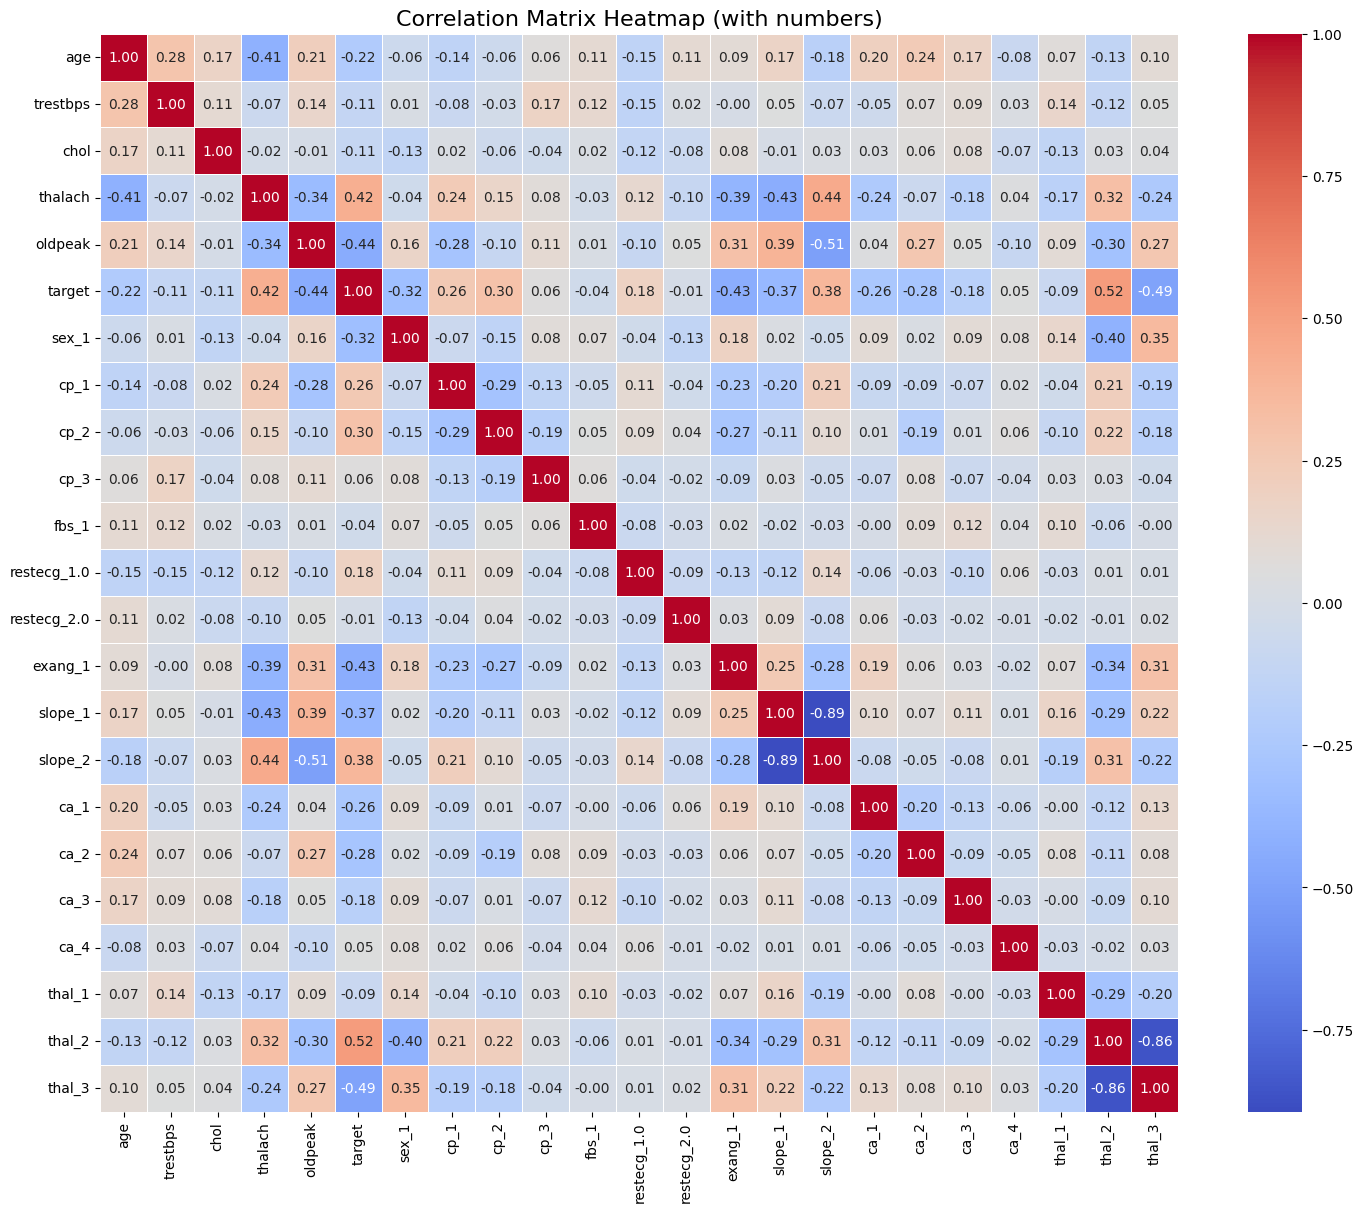

In [16]:
correlation_matrix = data.corr()
correlation_with_target = correlation_matrix['target'].sort_values(ascending=False)
print(correlation_with_target)
correlation_matrix = data.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Matrix Heatmap (with numbers)", fontsize=16)
plt.show()


In [17]:
important_features = correlation_with_target[abs(correlation_with_target) > 0.3].index.tolist()
important_features.remove('target')
print("Most important features for prediction:")
print(important_features)

print("Features strongly correlated with heart disease:")
print(important_features)

print("\nExplanation:")
print("- Features with higher absolute correlation influence prediction more.")

Most important features for prediction:
['thal_2', 'thalach', 'slope_2', 'cp_2', 'sex_1', 'slope_1', 'exang_1', 'oldpeak', 'thal_3']
Features strongly correlated with heart disease:
['thal_2', 'thalach', 'slope_2', 'cp_2', 'sex_1', 'slope_1', 'exang_1', 'oldpeak', 'thal_3']

Explanation:
- Features with higher absolute correlation influence prediction more.


In [18]:
cleaned_data_path = "heart_cleaned_data.csv"
data.to_csv(cleaned_data_path, index=False)

print(f"Cleaned data saved successfully at {cleaned_data_path}")

data.describe()

Cleaned data saved successfully at heart_cleaned_data.csv


,age,trestbps,chol,thalach,oldpeak,target
count,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000
mean,0.522727,0.472580,0.496294,0.543124,0.239161,0.555944
std,0.189410,0.201618,0.190267,0.198042,0.256427,0.497731
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.375000,0.342105,0.360043,0.407895,0.000000,0.000000
50%,0.541667,0.473684,0.482906,0.565789,0.150000,1.000000
75%,0.645833,0.605263,0.614316,0.699561,0.400000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
data.describe()


,age,trestbps,chol,thalach,oldpeak,target
count,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000
mean,0.522727,0.472580,0.496294,0.543124,0.239161,0.555944
std,0.189410,0.201618,0.190267,0.198042,0.256427,0.497731
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.375000,0.342105,0.360043,0.407895,0.000000,0.000000
50%,0.541667,0.473684,0.482906,0.565789,0.150000,1.000000
75%,0.645833,0.605263,0.614316,0.699561,0.400000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


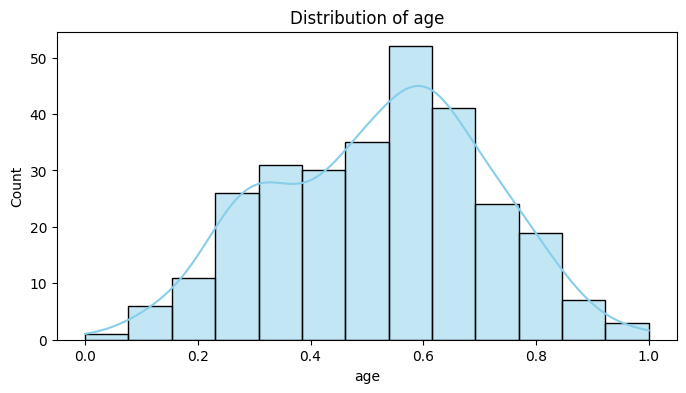

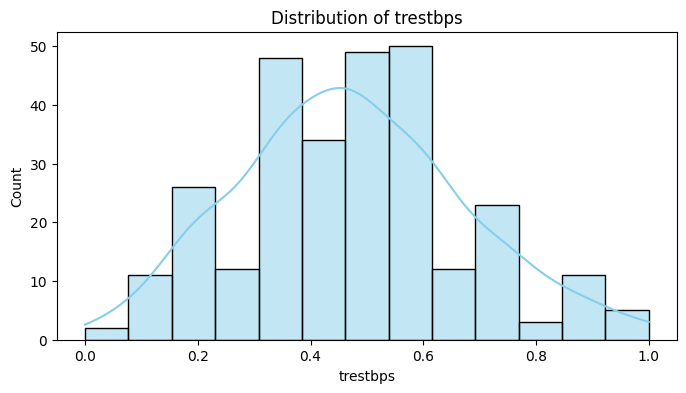

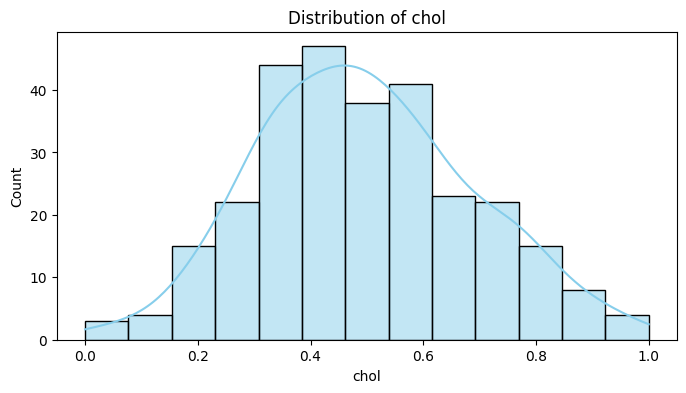

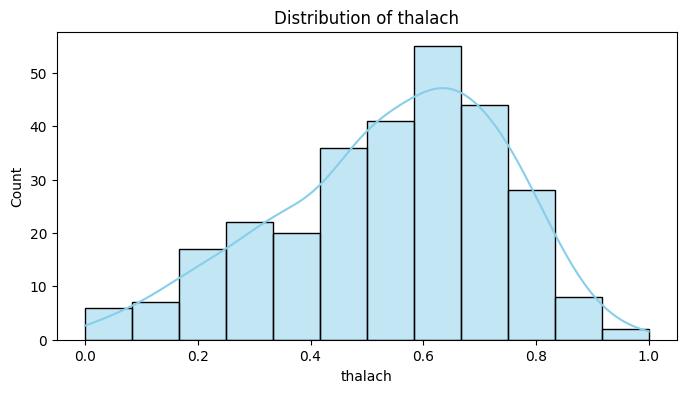

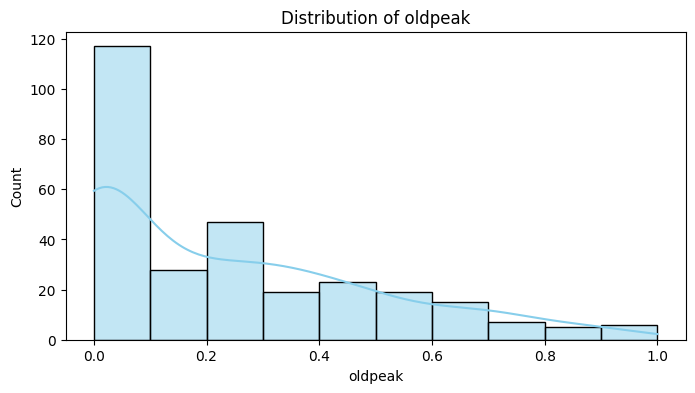

In [20]:
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for feature in key_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[feature], kde=True, color='skyblue')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()


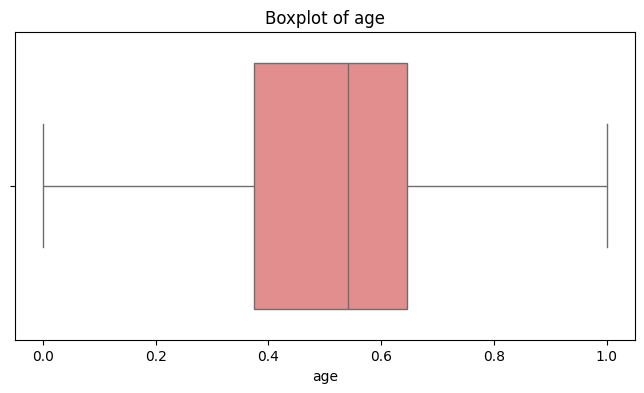

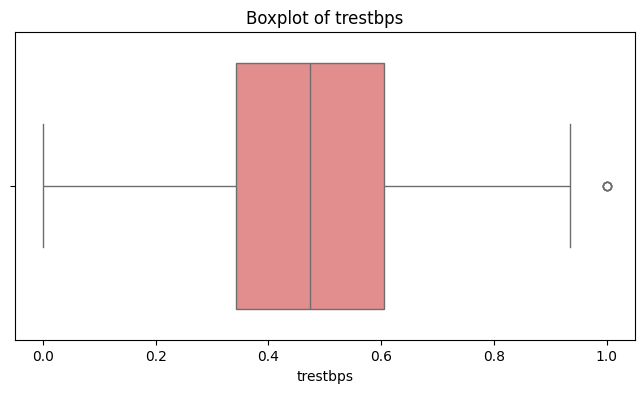

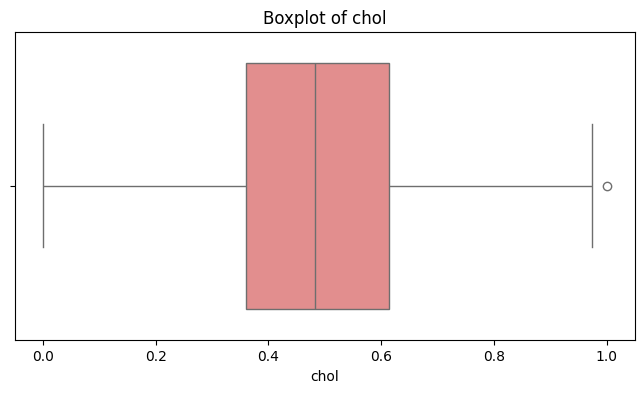

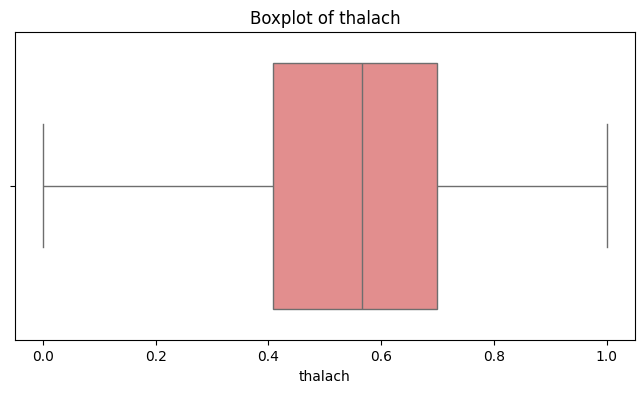

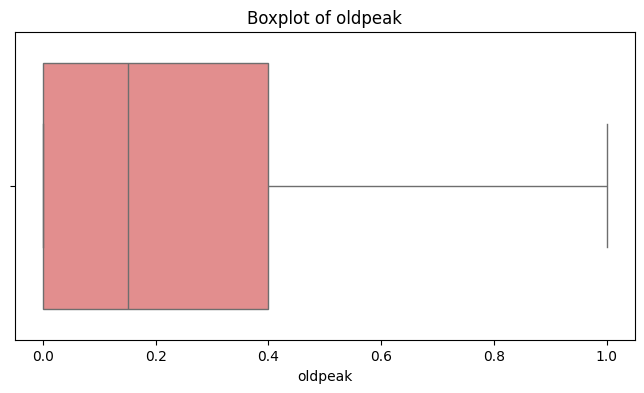

In [21]:
for feature in key_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[feature], color='lightcoral')
    plt.title(f"Boxplot of {feature}")
    plt.show()


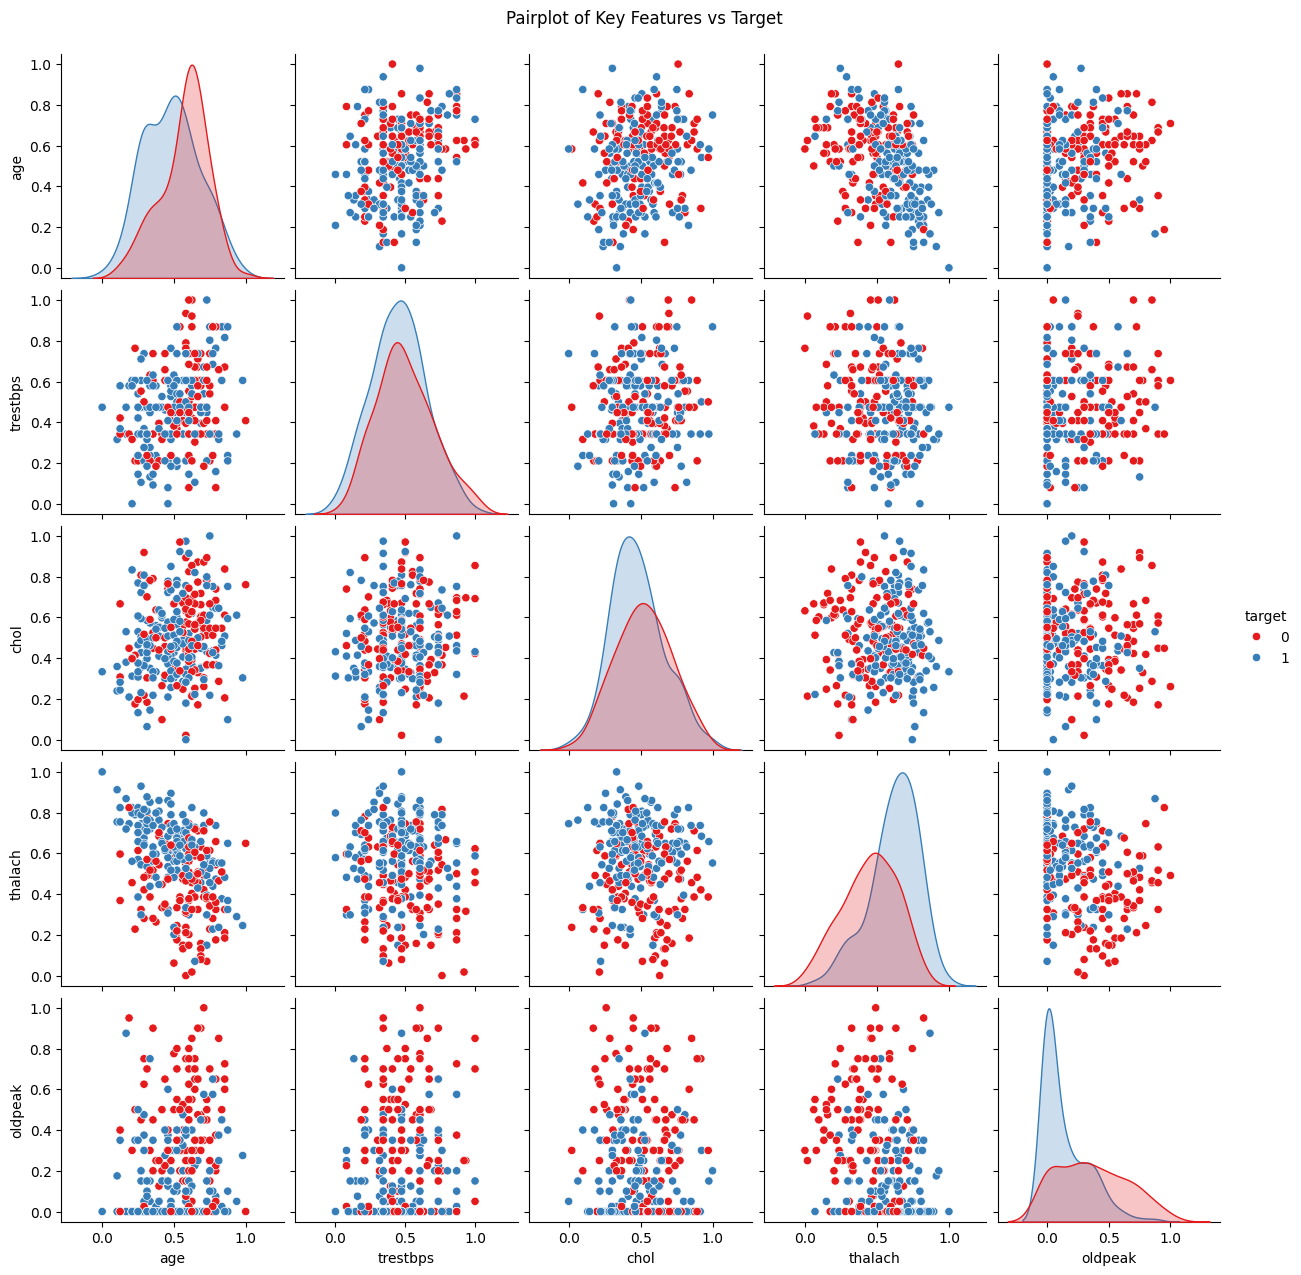

In [22]:
features_for_pairplot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

sns.pairplot(data[features_for_pairplot], hue='target', palette='Set1', diag_kind='kde')
plt.suptitle("Pairplot of Key Features vs Target", y=1.02)
plt.show()


/tmp/ipykernel_11466/1917280846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=data, palette='Set2')


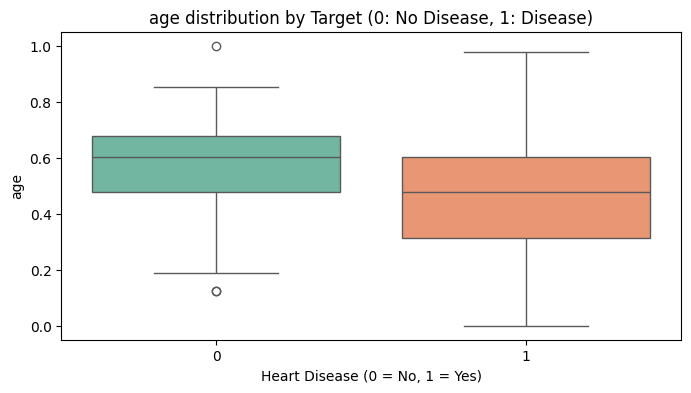

/tmp/ipykernel_11466/1917280846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=data, palette='Set2')


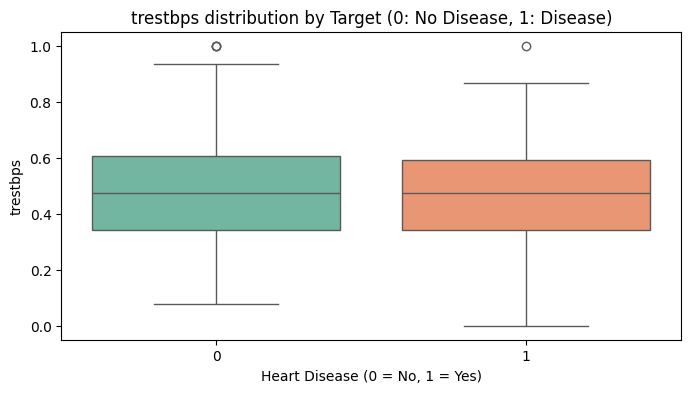

/tmp/ipykernel_11466/1917280846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=data, palette='Set2')


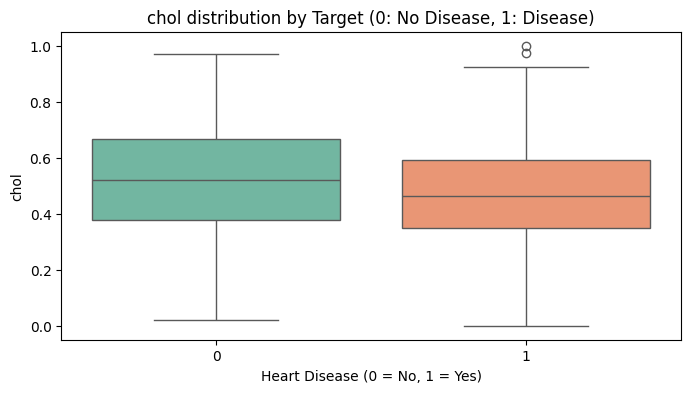

/tmp/ipykernel_11466/1917280846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=data, palette='Set2')


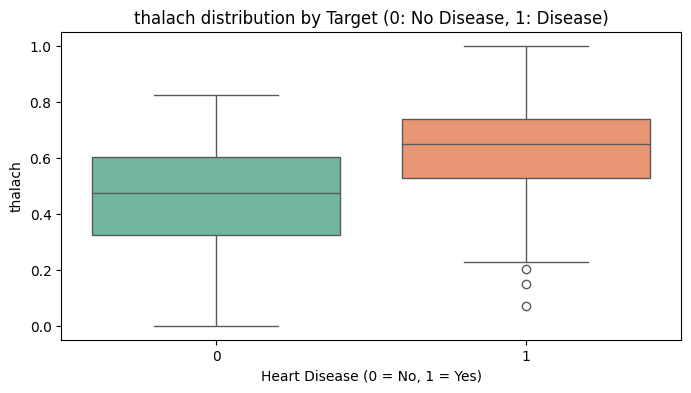

/tmp/ipykernel_11466/1917280846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=data, palette='Set2')


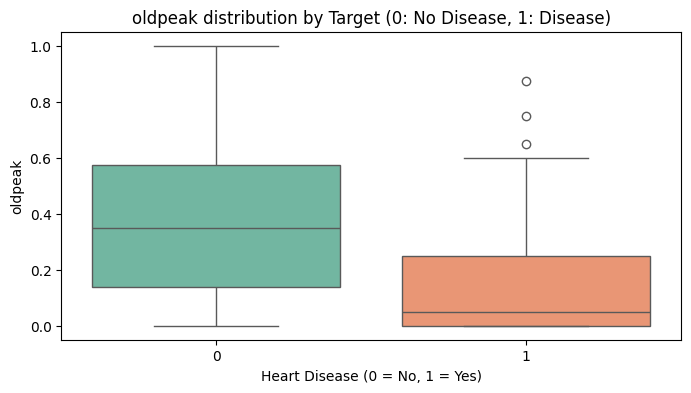

In [23]:
for feature in key_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='target', y=feature, data=data, palette='Set2')
    plt.title(f"{feature} distribution by Target (0: No Disease, 1: Disease)")
    plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
    plt.ylabel(feature)
    plt.show()


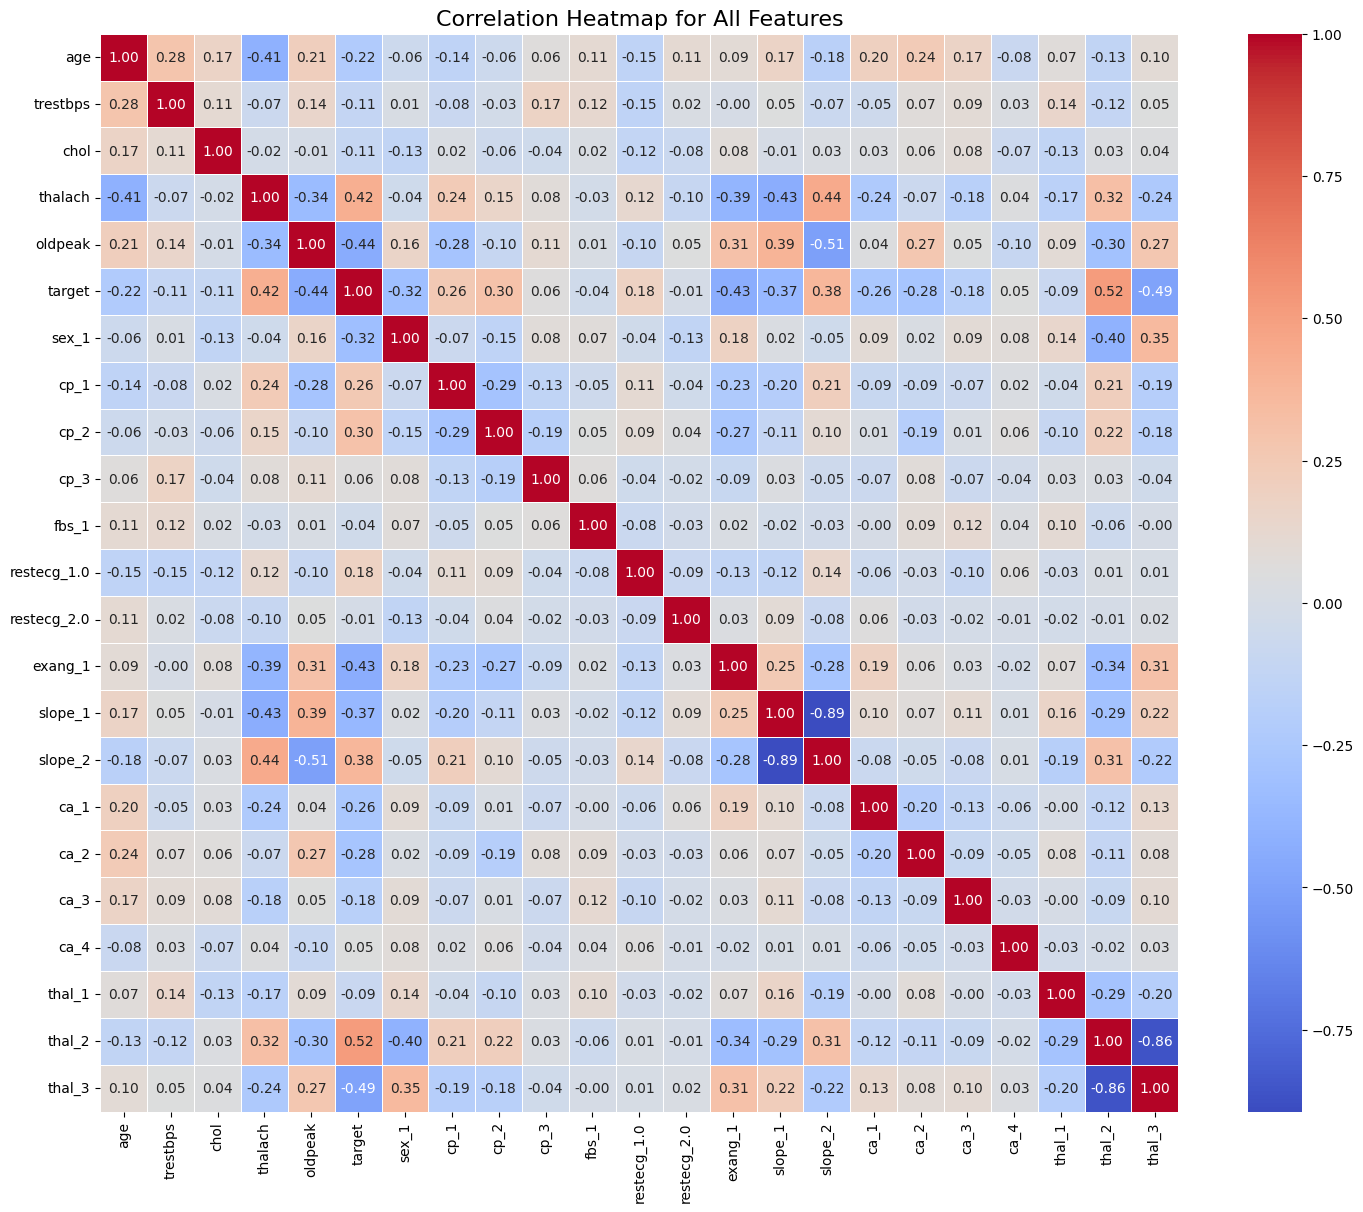

In [24]:
plt.figure(figsize=(18, 14))
sns.heatmap(data.corr(), cmap='coolwarm', annot=True, fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Heatmap for All Features", fontsize=16)
plt.show()


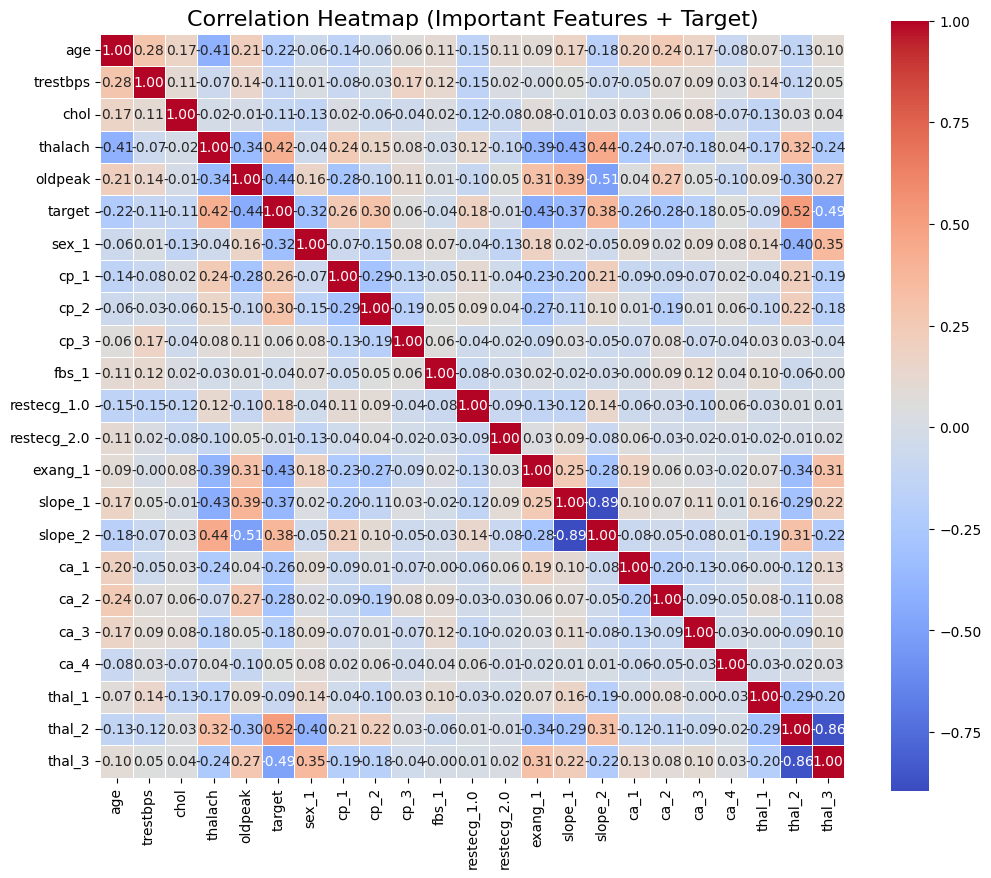

In [25]:
important_features_with_target = important_features + ['target']

plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), cmap='coolwarm', annot=True, fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Heatmap (Important Features + Target)", fontsize=16)
plt.show()


In [27]:
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

/tmp/ipykernel_11466/1663878020.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_data.head(15), palette='viridis')


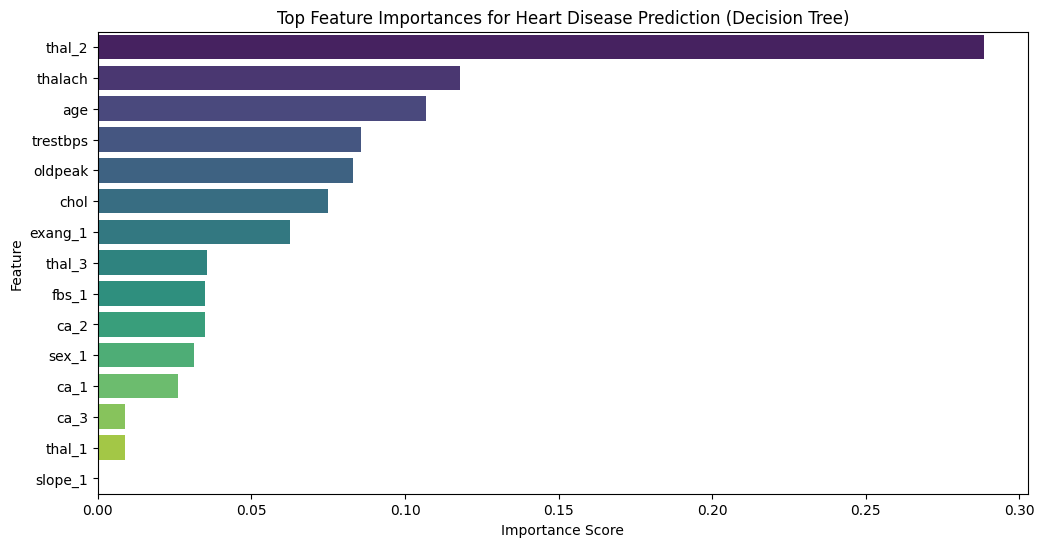

In [28]:
importances = dt_model.feature_importances_
feature_names = X.columns

importance_data = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_data.head(15), palette='viridis')
plt.title('Top Feature Importances for Heart Disease Prediction (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


/tmp/ipykernel_11466/3510254443.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


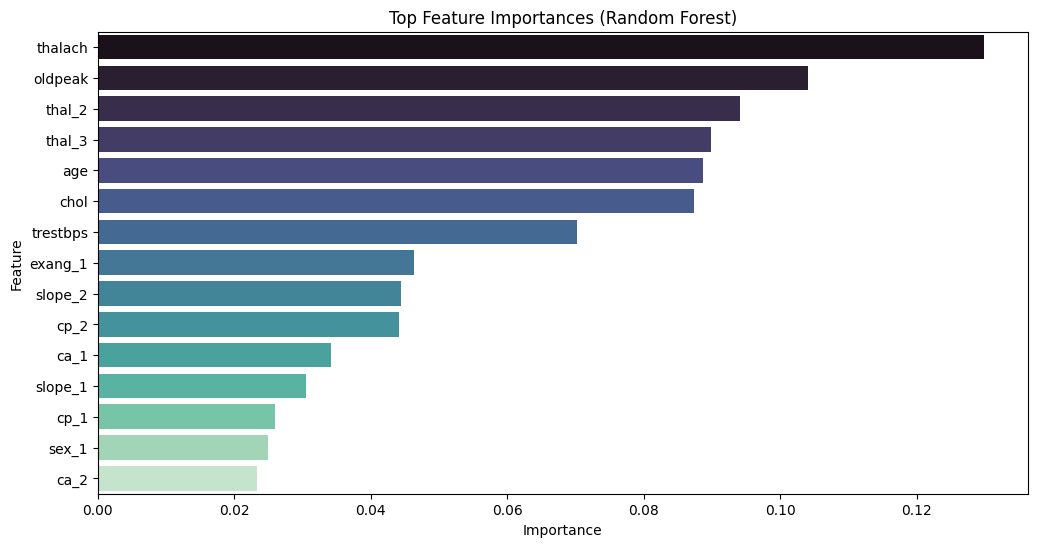

In [29]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_importances = rf_model.feature_importances_

rf_importance_data = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=rf_importance_data.head(15),
    palette='mako'
)

plt.title('Top Feature Importances (Random Forest)')
plt.show()
